# CRNN + YOLOV8N для чтения номеров

## Бибюдиотека и cuda

In [1]:

from pathlib import Path
import yaml
import json
from collections import Counter
import time
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import pandas as pd

from ultralytics import YOLO, RTDETR

import os
import torch
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')


C:\ProgramData\anaconda3\envs\dl-cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

print('=== Доступные устройства ===')
print(f'PyTorch версия: {torch.__version__}')

if torch.cuda.is_available():
    device = 'cuda'
    print(f'✅ CUDA доступна')
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
elif torch.backends.mps.is_available():
    device = 'mps'
    print(f'✅ MPS (Apple Silicon GPU) доступна')
    print(f'   Устройство: Apple Silicon (Metal)')
else:
    device = 'cpu'
    print(f'⚠️  Используется CPU')

print(f'\nВыбранное устройство: {device}')
print('=' * 40)

root = Path('.').resolve()
print(f'\nРабочая директория: {root}')

=== Доступные устройства ===
PyTorch версия: 2.5.1
✅ CUDA доступна
   GPU: NVIDIA GeForce RTX 4060 Ti
   Память: 17.18 GB

Выбранное устройство: cuda

Рабочая директория: C:\Users\user\Documents\VC\project


## CRNN
**EasyOCR** — библиотека с готовыми моделями для OCR на Python, CRNN — архитектура нейронной сети, которая сочетает свёрточные слои для извлечения признаков и рекуррентные слои для последовательной обработки текста.
Принцип работы:

1) 
Обнаружение — пиксельная сегментация текстовых областей
   
.3) 
Распознавание — предсказание последовательностей с языковым моделирование
   

5) .
Контекстная обработка — восстановление абзацев и сохранение порядка чтен
ия.

## берем лучшую YOLO +  crnn 

In [3]:
model = YOLO('yolov8n.pt')
total_params = sum(p.numel() for p in model.model.parameters())
batch_size = 32 if device == 'mps' else (16 if device == 'cuda' else 8)
epochs = 70

In [4]:
best_model_path = Path(r"C:\Users\user\Documents\VC\project\best.pt").resolve()
model_best = YOLO(str(best_model_path))

In [5]:
import easyocr
reader = easyocr.Reader(['ru', 'en'], gpu=True)

In [ ]:
data_dir = root / 'data'
images_dir = data_dir / 'images'
labels_dir = data_dir / 'labels'

assert images_dir.exists(), f'Директория {images_dir} не найдена. Запустите Workshop_2.ipynb'
assert labels_dir.exists(), f'Директория {labels_dir} не найдена. Запустите Workshop_2.ipynb'

image_files = sorted(list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png')))
label_files = sorted(list(labels_dir.glob('*.txt')))

print(f'Изображений: {len(image_files)}')
print(f'Файлов разметки: {len(label_files)}')

class_counts = Counter()
total_boxes = 0

for label_file in label_files:
    with open(label_file) as f:
        for line in f:
            if line.strip():
                cls_id = int(line.split()[0])
                class_counts[cls_id] += 1
                total_boxes += 1

print(f'\nВсего bounding boxes: {total_boxes}')
print(f'Распределение по классам:')
for cls_id, count in sorted(class_counts.items()):
    print(f'  Класс {cls_id}: {count} ({count/total_boxes*100:.1f}%)')

Изображений: 2787
Файлов разметки: 2787

Всего bounding boxes: 2962
Распределение по классам:
  Класс 0: 2962 (100.0%)


## чтение номеров с картинок

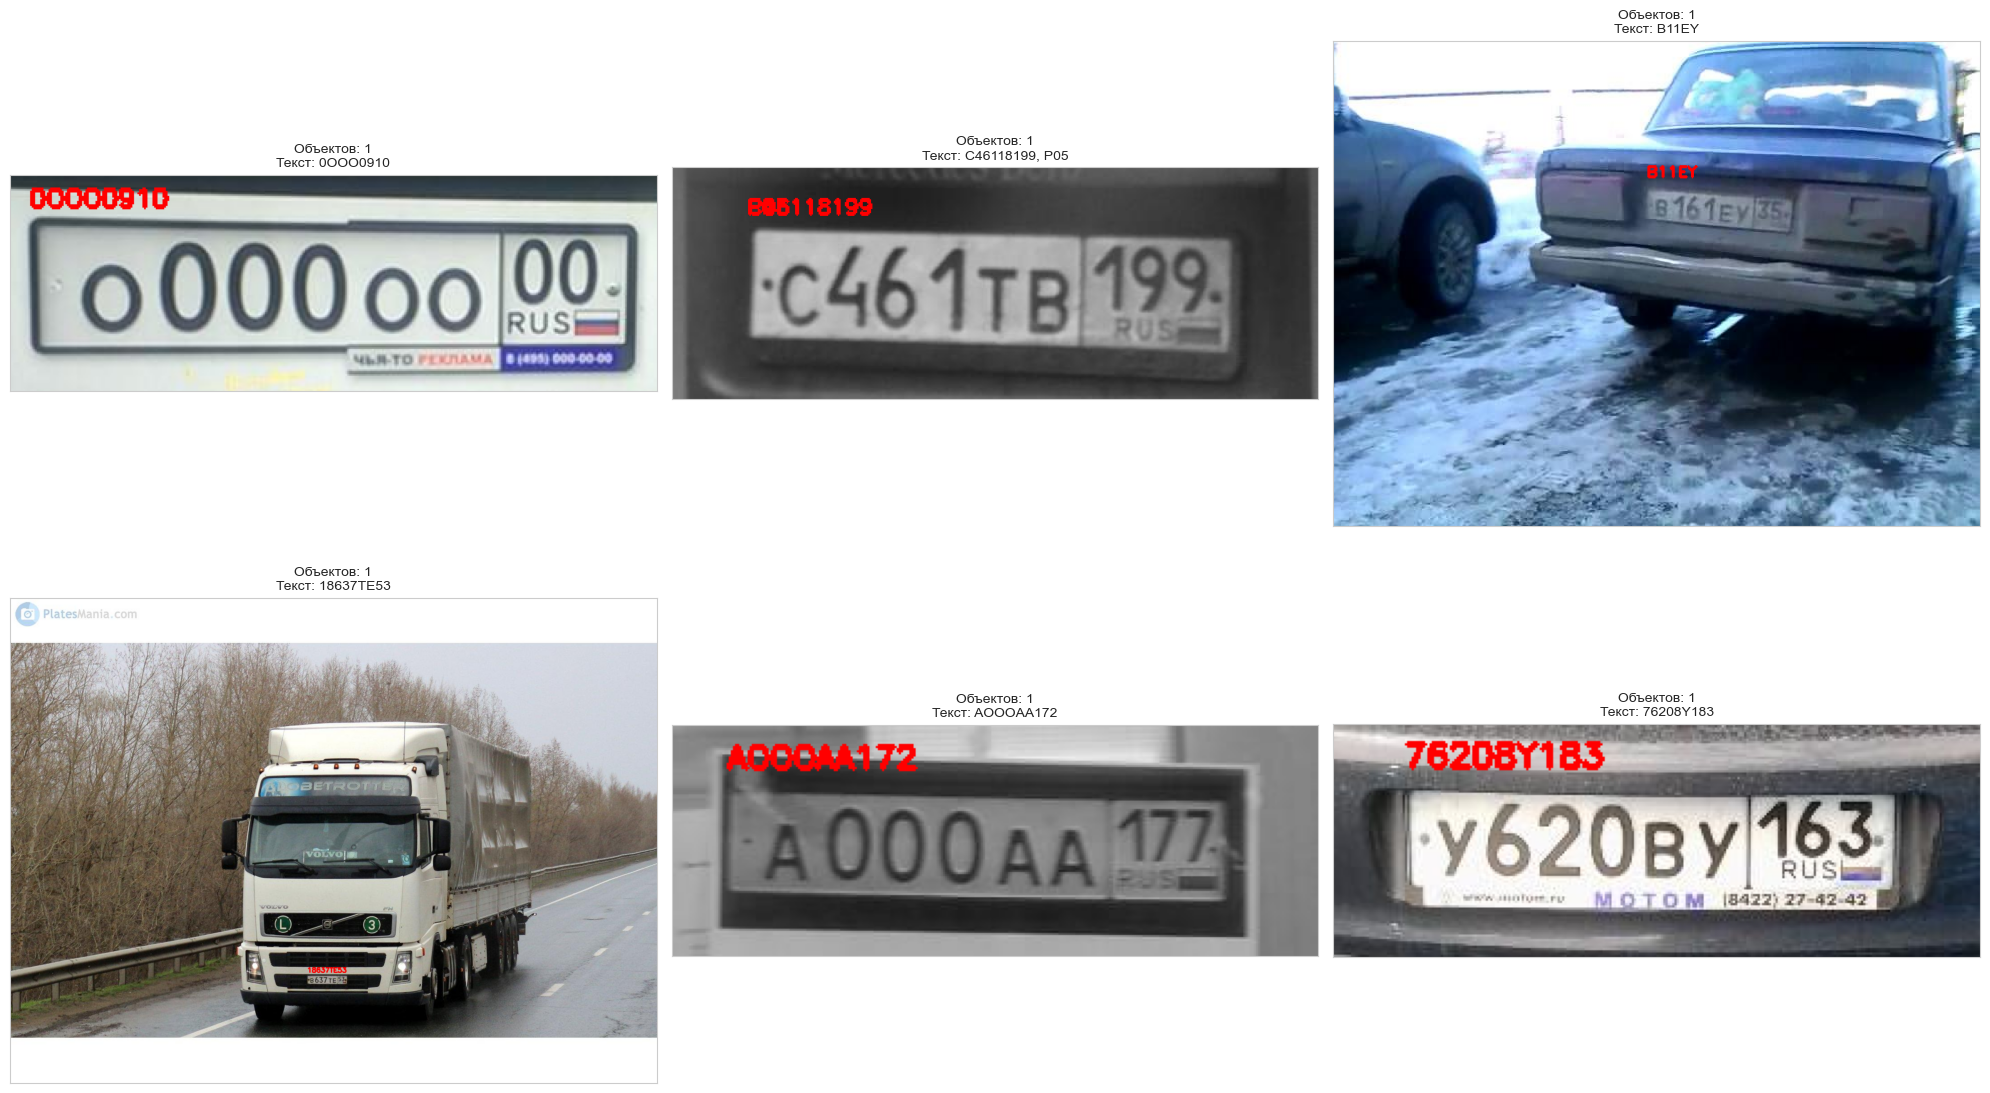

In [7]:
dataset_root = Path(r'C:\Users\user\Documents\VC\project\dataset_yolo').resolve()
test_images = sorted((dataset_root / 'test' / 'images').glob('*.jpg'))
test_images += sorted((dataset_root / 'test' / 'images').glob('*.png'))
np.random.seed(117)
sample_images = np.random.choice(test_images, size=min(6, len(test_images)), replace=False)
model_best_inference = model_best
inference_device = device
fig, axes = plt.subplots(2, 3, figsize=(20, 13), subplot_kw={'xticks': [], 'yticks': []})
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    results = model_best_inference(str(img_path), conf=0.25, iou=0.45,
                                   verbose=False, device=inference_device)

    orig_image = cv2.imread(str(img_path))
    orig_image_rgb = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
    boxes = results[0].boxes
    detected_texts = []
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        text_roi = orig_image[y1:y2, x1:x2]
        if text_roi.size > 0:
            text_roi_rgb = cv2.cvtColor(text_roi, cv2.COLOR_BGR2RGB)
            ocr_results = reader.readtext(
                text_roi_rgb,
                batch_size=1,
                allowlist='0123456789ABEKMHOPCTYX',
                paragraph=False,
                detail=1,
                width_ths=0.9,
                height_ths=0.9,
                ycenter_ths=0.5
            )

            if ocr_results:
                for ocr_result in ocr_results:
                    _, text, _ = ocr_result
                    detected_texts.append(text)
                    cv2.putText(orig_image_rgb, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            else:
                detected_texts.append("Не распознано")
        else:
            detected_texts.append("Пустая область")
    axes[idx].imshow(orig_image_rgb)
    title_text = f'Объектов: {len(boxes)}\n'
    if detected_texts:
        title_text += f'Текст: {", ".join(detected_texts[:3])}'
        if len(detected_texts) > 3:
            title_text += '...'

    axes[idx].set_title(title_text, fontsize=10)

plt.tight_layout()
plt.show()

## чтение номеров с видео

In [13]:
video_path = r'C:\Users\user\Documents\VC\project\vecteezy_traffic-cars-passing-in-road-with-asphalt-with-cracks-seen_36990287.MOV'

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_path = str('processed_video.mp4')
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

In [14]:
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    print(f"Обработка кадра {frame_count}", end='\r')
    
    orig_image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    results = model_best_inference(orig_image_rgb, conf=0.25, iou=0.45,
                                   verbose=False, device=inference_device)
    
    boxes = results[0].boxes
    detected_texts = []
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        
        text_roi = frame[y1:y2, x1:x2]
        
        if text_roi.size > 0:
            text_roi_rgb = cv2.cvtColor(text_roi, cv2.COLOR_BGR2RGB)
            
            ocr_results = reader.readtext(
                text_roi_rgb,
                batch_size=1,
                allowlist='0123456789ABEKMHOPCTYX',
                paragraph=False,
                detail=1,
                width_ths=0.9,
                height_ths=0.9,
                ycenter_ths=0.5
            )

            if ocr_results:
                for ocr_result in ocr_results:
                    _, text, _ = ocr_result
                    detected_texts.append(text)
                    
                    cv2.putText(frame, text, (x1, y1 - 10), 
                              cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                    
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            else:
                detected_texts.append("???")
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

    
    info_text = f"frame: {frame_count} | Object: {len(boxes)}"
    cv2.putText(frame, info_text, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    if detected_texts:
        text_display = f"Registration_Plates: {', '.join(detected_texts[:3])}"
        if len(detected_texts) > 3:
            text_display += "..."
        cv2.putText(frame, text_display, (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    
    out.write(frame)
    
    if frame_count % 10 == 0:
        preview = cv2.resize(frame, (width//2, height//2))
        cv2.imshow('Preview', preview)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
out.release()
cv2.destroyAllWindows()